In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
def get_image_input(sim_no,output,r):
    import pandas as pd
    import numpy as np
    import os
    sim = 998
    nodes = 9271
    file = f'csv_files/sim_w_comb_{sim_no}/S_U_PEEQ_COORD_{sim_no}.csv'
    if os.path.isfile(file):
       
        df = pd.read_csv(file)
        df = df.replace('       NoValue', np.nan)
        df.columns = df.columns.str.lstrip()
        x_cord = df['X']
        y_cord = df['Y']
        rho = np.zeros(len(y_cord))
        phi = np.zeros(len(y_cord))
        for i in range((len(x_cord))):
            rho[i] = np.sqrt(x_cord[i]**2 + y_cord[i]**2)
            phi[i] = np.arctan2(y_cord[i], x_cord[i])
        df = df.drop(columns = 'X')
        df = df.drop(columns = 'Y')
        df['R'] = rho
        df['theta'] = phi
        df_data = df[(df['R'] > r-10) & (df['R'] < r+10)]
        df_data = df_data.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
        data_S11 = df_data['S-S11'].values
        data_S22 = df_data['S-S22'].values
        data_S33 = df_data['S-S33'].values
        data_S12 = df_data['S-S12'].values
        data_r = df_data['R'].values
        data_theta = df_data['theta'].values
        if output == 'sigmax':
            return (data_S11)
        if output == 'sigmay':
            return (data_S12)
        if output == 'sigmaz':
            return (data_S33)
        if output == 'r':
            return(data_r)
        if output == 'theta':
            return(data_theta)

In [3]:
len1 = len(get_image_input(5,'sigmax',500))
len2 = len(get_image_input(5,'sigmax',1500))

In [4]:
temp_in= []
temp_ex = []
for i in range(10):
    file = f'csv_files/sim_w_comb_{i}/S_U_PEEQ_COORD_{i}.csv'
    if os.path.isfile(file):
        temp_in.append(i)
    else:
        temp_ex.append(i)
def get_xinput(r,len2):
    import numpy as np
    sim_count = len(temp_in)
    a = np.zeros((len1,10))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r)
    return a
x_input = get_xinput(500,len2)

In [3]:
len1 = len(get_image_input(5,'sigmax',500))
len2 = len(get_image_input(5,'sigmax',1500))

In [4]:
temp_in= []
temp_ex = []
for i in range(977):
    file = f'csv_files/sim_w_comb_{i}/S_U_PEEQ_COORD_{i}.csv'
    if os.path.isfile(file):
        temp_in.append(i)
    else:
        temp_ex.append(i)

In [5]:
def get_xinput(r,len1):
    import numpy as np
    sim_count = len(temp_in)
    a = np.zeros((128,977))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r)
    return a
x_input = get_xinput(500,len)

# Image Geneartion from Input data

In [6]:
!pip install tab2img

In [7]:
from sklearn.datasets import fetch_covtype
from tab2img.converter import Tab2Img

dataset = fetch_covtype()

train = dataset.data
target = dataset.target

model = Tab2Img()
images = model.fit_transform(train, target)

In [8]:
from pyDeepInsight import ImageTransformer, LogScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [9]:
ln = LogScaler()
X_train_norm = ln.fit_transform(x_input)

In [10]:
X_train_norm.reshape(1,-1)

array([[0.07721387, 0.08197073, 0.14551425, ..., 0.        , 0.        ,
        0.        ]])

In [11]:
X_train_norm.shape

(128, 977)

In [12]:
it = ImageTransformer(feature_extractor='tsne', 
                      pixels = 300 , random_state=0, 
                      n_jobs=-1)

In [41]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity= 50, metric='cosine',
            random_state=10, n_jobs=-1)

it = ImageTransformer(feature_extractor=tsne, pixels= 30)

In [42]:
X_train_norm1 = X_train_norm[:,0]
X_train_norm1.reshape(1,-1).shape

(1, 128)

C:\Users\ssinghai6\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\ssinghai6\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\ssinghai6\Anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:819: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(


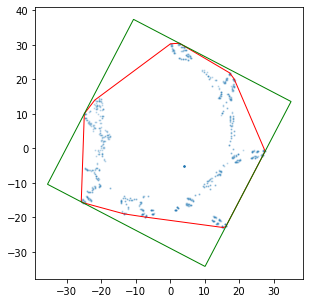

In [43]:
plt.figure(figsize=(5, 5))
_ = it.fit(X_train_norm, plot=True)

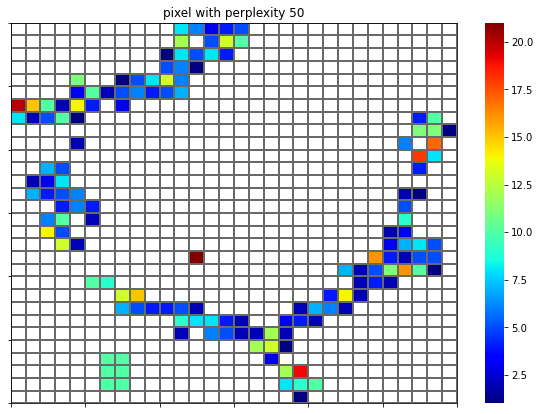

In [44]:
fdm = it.feature_density_matrix()
fdm[fdm == 0] = np.nan

plt.figure(figsize=(10, 7))

ax = sns.heatmap(fdm, cmap="jet", linewidths=0.01, 
                 linecolor="dimgrey", square= False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
for _, spine in ax.spines.items():
    spine.set_visible(True)
_ = plt.title("pixel with perplexity 50")